In [1]:
import numpy as np
from numpy.lib.stride_tricks import as_strided
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Generally useful code

For now:
- windowed scoring (stationary score function)
- per-step normalization
- episode-level calibration

sentinel values:
fail = np.inf
H = np.inf

In [2]:
def split_indices(n, sizes: dict[str, float], seed=0) -> dict[str, np.ndarray]:
    """Random disjoint partition of range(n).
    
    sizes: {name: fraction}, must sum to 1.
    Returns {name: indices}, preserving insertion order.
    """
    assert abs(sum(sizes.values()) - 1.0) < 1e-9
    fracs = np.fromiter(sizes.values(), dtype=float)
    cuts  = (np.cumsum(fracs)[:-1] * n).astype(int)
    parts = np.split(np.random.default_rng(seed).permutation(n), cuts)
    return dict(zip(sizes, parts))

Dataset is a list of tensors
Can have a axis-0 split
The splits should pass correctly through normalization (fit on train split only)

Leave reduction of train split windows to train step (method-specific)

In [3]:
class Dataset:
    """Aligned arrays sharing axis 0."""
    def __init__(self, **arrays):
        lens = {a.shape[0] for a in arrays.values()}
        assert len(lens) == 1, f"Mismatched leading axes: {lens}"
        self._a = arrays
    
    def __len__(self):         return next(iter(self._a.values())).shape[0]
    def __getitem__(self, i):  return Dataset(**{k: a[i] for k, a in self._a.items()})
    def __getattr__(self, name):
          if name.startswith('_'): raise AttributeError(name)
          try:    return self._a[name]
          except KeyError: raise AttributeError(name)
    def __repr__(self):
          fields = ", ".join(f"{k}: {a.shape}" for k, a in self._a.items())
          return f"Dataset({fields})"
    
    def split(self, sizes, seed=0): # returns Dict[str, Dataset]
          idx = split_indices(len(self), sizes, seed=seed)
          return {k: self[v] for k, v in idx.items()}
    
    def where(self, mask):
        return self[mask]
    def map(self, **fns):
        return Dataset(**{k: fns.get(k, lambda x: x)(a) for k, a in self._a.items()})
    def assign(self, **new):
        return Dataset(**{**self._a, **new})

# some utility functions

def successes(ds): return ds[ds.fail == np.inf]

def failures(ds):  return ds[np.isfinite(ds.fail)]

def prop_succ(ds): return (ds.fail == np.inf).mean()

def get_ds(env: str, obs_only: bool = True) -> Dataset:
    d = np.load(Path(f'../data/{env}/fail_pred/data.npz'))
    X = d['X']
    if obs_only:
      from config.envs import ENV_INFO
      sl = ENV_INFO[env].obs_slice
      if sl is not None:
          X = X[..., sl]
    fail = np.where(d['fail'] < 0, np.inf, d['fail'].astype(float))
    return Dataset(X=X, fail=fail)

ds = get_ds('ant')

In [4]:
def stratified_split(ds: Dataset,
                     sizes, 
                     success_only=(), 
                     seed=0
                    ) -> dict[str, Dataset]:
      ss = successes(ds).split(sizes, seed=seed)

      fail_sizes = {k: v for k, v in sizes.items() if k not in success_only}
      total      = sum(fail_sizes.values())
      if total > 0 and len(failures(ds)) > 0:
          fail_sizes = {k: v / total for k, v in fail_sizes.items()}
          fs = failures(ds).split(fail_sizes, seed=seed + 1)
      else:
          fs = {}

      def cat(a, b):
          if a is None: return b
          if b is None: return a
          return Dataset(**{k: np.concatenate([a._a[k], b._a[k]]) for k in a._a})

      return {k: cat(ss.get(k), fs.get(k)) for k in sizes}

splits = stratified_split(ds,
  sizes={'train': 0.4, 'norm': 0.2, 'cal': 0.2, 'test': 0.2},
  success_only=('norm', 'cal'),
)
splits

{'train': Dataset(X: (972, 1000, 27), fail: (972,)),
 'norm': Dataset(X: (270, 1000, 27), fail: (270,)),
 'cal': Dataset(X: (270, 1000, 27), fail: (270,)),
 'test': Dataset(X: (488, 1000, 27), fail: (488,))}

In [5]:
prop_succ(splits['train']), prop_succ(splits['test'])

(np.float64(0.5555555555555556), np.float64(0.555327868852459))

For now, assume fail[i] is the first failed timestep, so fail[i:] is the failed region.

- H = 0: must end strictly before failure

In [6]:
# Numpy primitives:

def window(X, W, stride):
  """(N, T, D) -> (N, n_win, W, D). Strided view; no copy."""
  N, T, D = X.shape
  n_win = (T - W) // stride + 1
  return as_strided(
      X, shape=(N, n_win, W, D),
      strides=(X.strides[0], X.strides[1] * stride, X.strides[1], X.strides[2]),
  )


def is_id(fail, ends, H):
  """In-distribution mask: (N,), (n_win,) -> (N, n_win) bool.

  Assumes fail uses np.inf for successes. A window is ID iff its end
  is more than H timesteps before its episode's failure.
  """
  return fail[:, None] >= ends[None, :] + H

type(window(ds.X, W=50, stride=50))

numpy.ndarray

In [7]:
def get_id_windows(ds, W, stride, H) -> np.ndarray:
    """ID-filtered flat window bag from a trajectory dataset.
    
    Expects ds.X: (N, T, D) and ds.fail: (N,) with np.inf for successes.
    Returns (M, W, D): the flat bag of windows whose ends are more than
    H steps before their episode's failure.
    """
    windows = window(ds.X, W, stride)
    ends    = np.arange(windows.shape[1]) * stride + W - 1
    return windows[is_id(ds.fail, ends, H)]

get_id_windows(ds, W=70, stride=50, H=70).shape

(29513, 70, 27)

In [8]:
def normalize_channels(splits, fit_on='train'):
    from sklearn.preprocessing import StandardScaler
    
    X_fit  = splits[fit_on].X
    D      = X_fit.shape[-1]
    scaler = StandardScaler().fit(X_fit.reshape(-1, D))
    apply  = lambda X: scaler.transform(X.reshape(-1, D)).reshape(X.shape)
    return {k: s.map(X=apply) for k, s in splits.items()}

splits = ds.split({'train': 0.4, 'norm': 0.2, 'cal': 0.2, 'test': 0.2}, seed=0)
splits = normalize_channels(splits)

In [9]:
class GaussianDetector:
  def __init__(self, win):
      self.win = win

  def fit(self, windows):              # (M, W, D)
      flat = windows.reshape(len(windows), -1)
      self.mean = flat.mean(axis=0)
      self.std  = flat.std(axis=0) + 1e-8
      return self

  def score(self, windows):            # (M, W, D) -> (M,)
      flat = windows.reshape(len(windows), -1)
      return (((flat - self.mean) / self.std) ** 2).sum(axis=1)

In [10]:
def score_windows(detector, windows):
    """Score structured windows, preserving (N, n_win) layout.
    
    windows : (N, n_win, W, D)
    returns : (N, n_win) scores
    
    Detector contract: `detector.score(bag: (M, W, D)) -> (M,)`.
    """
    N, n_win = windows.shape[:2]
    flat = windows.reshape(-1, *windows.shape[2:])
    return detector.score(flat).reshape(N, n_win)

In [11]:
def detection_metrics(z, ends, threshold, fail):
  """FPR, detection rate, median TTD.

  z         : (N, n_win) normalized score array
  ends      : (n_win,) window-end timesteps
  threshold : float
  fail      : (N,) — np.inf for successes, else failure timestep

  Undetectable failures (fail < ends[0]) are dropped from det_rate.
  """
  succ_mask = fail == np.inf
  fail_ep   = np.where(np.isfinite(fail))[0]
  fail_ep   = fail_ep[fail[fail_ep] >= ends[0]]

  fpr = (z[succ_mask] > threshold).any(axis=1).mean() * 100

  lead = []
  for i in fail_ep:
      alarms = ends[z[i] > threshold]
      early  = alarms[alarms <= fail[i]]
      if len(early):
          lead.append(fail[i] - early[0])

  det_rate = len(lead) / len(fail_ep) * 100 if len(fail_ep) else float('nan')
  med_ttd  = float(np.median(lead)) if lead else float('nan')
  return {'fpr': fpr, 'det_rate': det_rate, 'med_ttd': med_ttd}

def max_conformal_threshold(scores, alpha):
  """Max-conformal threshold at target FPR alpha.

  scores : (N_cal, n_win) — normalized calibration scores (successes)
  """
  n = len(scores)
  q = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
  return float(np.quantile(scores.max(axis=1), q))

def fit_znorm(scores, axis=0):
  """Fit per-axis z-score on scores; return the apply-closure."""
  mean = scores.mean(axis=axis)
  std  = scores.std(axis=axis) + 1e-8
  return lambda s: (s - mean) / std

def score_trajectories(detector, ds, W, stride):
    """(detector, trajectory dataset) -> (N, n_win) score array."""
    print(f'Scoring {len(ds.X)} trajs') 
    return score_windows(detector, window(ds.X, W, stride))

In [12]:
def get_results(detector_factory, ds, W, stride, H, alpha=0.1, seed=0):
    # split
    splits = stratified_split(ds,
          sizes={'train': 0.4, 'norm': 0.2, 'cal': 0.2, 'test': 0.2},
          success_only=('norm', 'cal'),
          seed=seed,
    )
    splits = normalize_channels(splits, fit_on='train')

    # train
    win_tr = get_id_windows(splits['train'], W, stride, H)
    print(f'Train on {win_tr.shape}')
    detector = detector_factory(W).fit(win_tr)

    # norm + cal
    znorm     = fit_znorm(score_trajectories(detector, successes(splits['norm']), W, stride)) # normalization
    threshold = max_conformal_threshold( # calibration
      znorm(score_trajectories(detector, successes(splits['cal']), W, stride)),
      alpha,
    )

    # test
    z_te = znorm(score_trajectories(detector, splits['test'], W, stride))
    ends = np.arange(z_te.shape[1]) * stride + W - 1
    
    return dict(
      **detection_metrics(z_te, ends, threshold, splits['test'].fail),
      threshold=threshold, z_te=z_te, ends=ends,
      fail_te=splits['test'].fail,
    )

In [13]:
ds = get_ds('hopper')
W, H, stride = 70, 70, 5
alpha, seed  = 0.1, 0
res = get_results(lambda W: GaussianDetector(win=W), ds, W, stride, H, alpha, seed)

print(f'FPR: {res['fpr']}')
print(f'Det: {res['det_rate']}')
print(f'TTD: {res['med_ttd']}')

Train on (161324, 70, 11)
Scoring 221 trajs
Scoring 220 trajs
Scoring 521 trajs
FPR: 12.217194570135746
Det: 100.0
TTD: 305.0


<Axes: xlabel='timestep', ylabel='normalized score'>

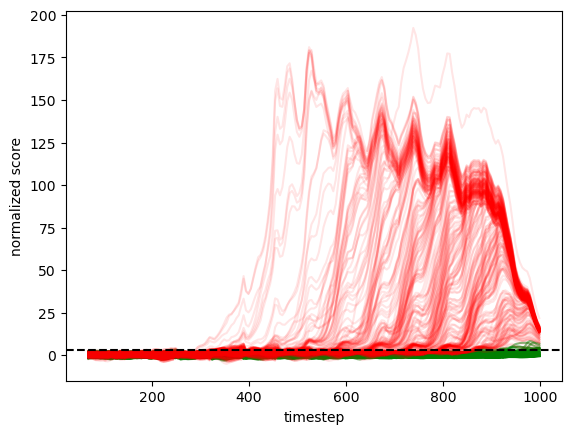

In [14]:
def print_results(res):
    print(res['fpr'], res['det_rate'], res['med_ttd'])

def plot_results(res, ax=None):
    """Per-episode normalized test scores vs window-end timestep, with threshold."""
    if ax is None:
      ax = plt.gca()
    succ = res['fail_te'] == np.inf
    t    = res['ends']
    ax.plot(t, res['z_te'][succ].T,  color='green', alpha=0.5)
    ax.plot(t, res['z_te'][~succ].T, color='red',   alpha=0.1)
    ax.axhline(res['threshold'], color='k', linestyle='--')
    ax.set_xlabel('timestep')
    ax.set_ylabel('normalized score')
    return ax

plot_results(res)

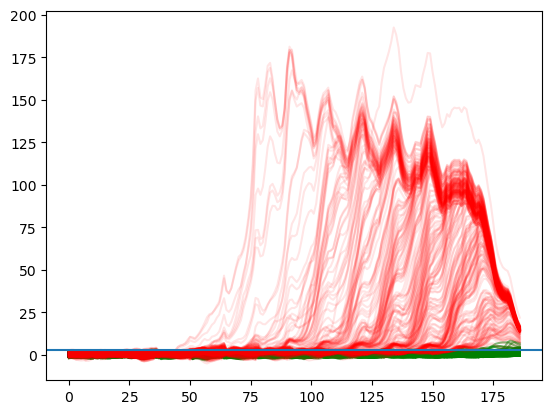

In [17]:
succ = res['fail_te'] == np.inf

plt.plot(res['z_te'][succ].T, color='green', alpha=0.5);
plt.plot(res['z_te'][~succ].T, color='red', alpha=0.1);
plt.axhline(res['threshold'])

# Trying out flows

In [39]:
ds = get_ds('inv_pend')

In [40]:
split = stratified_split(ds, {'train': 0.5, 'cal': 0.25, 'test': 0.25}, success_only=('train','cal'))

In [41]:
split = normalize_channels(split)

In [65]:
from flowjax.flows import block_neural_autoregressive_flow
from flowjax.train import fit_to_data
from flowjax.distributions import Normal
import jax.random as jr
import jax.numpy as jnp

data_key, flow_key, train_key, sample_key = jr.split(jr.key(0), 4)

In [22]:
split['train']

Dataset(X: (551, 1000, 11), fail: (551,))

In [23]:
flow = block_neural_autoregressive_flow(
    key=flow_key,
    base_dist=Normal(jnp.zeros(split['train'].X.shape[-1])),
)

In [24]:
x_tr = split['train'].X
x_tr = x_tr.reshape(-1, x_tr.shape[-1])

In [25]:
x_tr.shape

(551000, 11)

In [26]:
flow, losses = fit_to_data(
    key=train_key,
    dist=flow,
    data=x_tr,
    learning_rate=5e-3,
    max_epochs=20,
    )

100%|████████████████████████████| 20/20 [01:57<00:00,  5.87s/it, train=-8.47, val=-8.61]


In [27]:
score = lambda x: -flow.log_prob(x)
x_te = split['test'].X
x_cal = split['cal'].X
x_te.shape

(1174, 1000, 11)

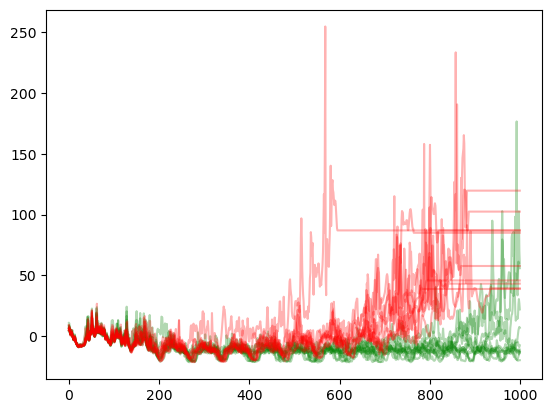

In [28]:
plt.plot(score(x_te[:10]).T, color='green', alpha=0.3)
plt.plot(score(x_te[-10:]).T, color='red', alpha=0.3)

In [29]:
scores = score(x_cal)

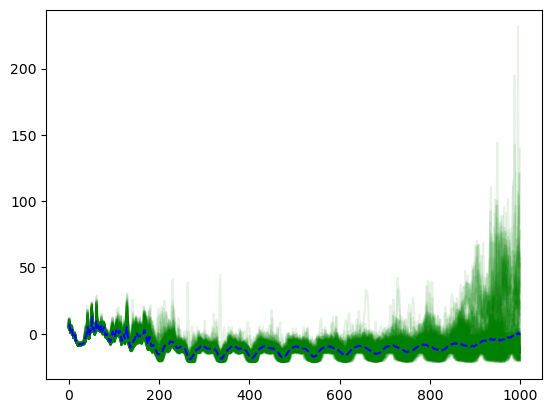

In [30]:
plt.plot(scores.T, color='green', alpha=0.1);
plt.plot(scores.mean(axis=0), 'b--')

In [66]:
def flow_detector(W):
    class Det:
        def __init__(self): self.win = W
        def fit(self, w):  # w: (M, W, D)
            from flowjax.flows import block_neural_autoregressive_flow
            from flowjax.train import fit_to_data
            x = w.reshape(len(w), -1)
            f = block_neural_autoregressive_flow(
                key=jr.key(0), base_dist=Normal(jnp.zeros(x.shape[-1])),
            )
            self.flow, _ = fit_to_data(
                key=jr.key(1), dist=f, data=x,
                learning_rate=5e-3, max_epochs=20,
            )
            return self
        def score(self, w):  # (M, W, D) -> (M,)
            return np.asarray(-self.flow.log_prob(w.reshape(len(w), -1)))
    return Det()

ds = get_ds('inv_pend')
res = get_results(flow_detector, ds, W=1, stride=100, H=np.inf, alpha=0.1, seed=0)
print_results(res)

Train on (6060, 1, 4)


100%|█| 20/20 [00:01<00:00, 10.37it/s, train


Scoring 303 trajs
Scoring 303 trajs
Scoring 465 trajs
12.871287128712872 29.01234567901235 21.0


In [32]:
res.keys()

dict_keys(['fpr', 'det_rate', 'med_ttd', 'threshold', 'z_te', 'ends', 'fail_te'])

15.302491103202847 42.211055276381906 26.5


<Axes: xlabel='timestep', ylabel='normalized score'>

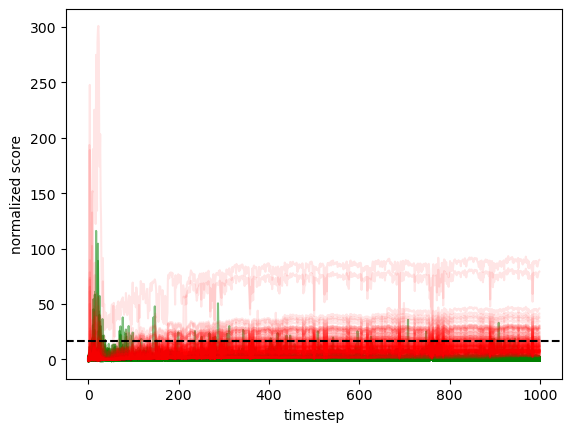

In [33]:
print(res['fpr'], res['det_rate'], res['med_ttd'])
plot_results(res)

In [34]:
# base -> data (z -> x) for sampling
flow.bijection.transform;

# data -> base (x -> z) used for log_prob, encoding
# this is the cheap direction
flow.bijection.inverse;

In [35]:
import jax

encode = jax.vmap(jax.vmap(flow.bijection.inverse))
z_te = encode(x_te[:10]).shape

# Experiment 2

For state-based safety monitoring (W=1), let's compare CD, NF with logp score, NF with CD score.
We'll do it on Hopper.

Train on (121200, 1, 4)
Data monomials shape: torch.Size([121200, 35])
Moment matrix cond num: 3.096959e+07
Empirical mean of CD poly: 35.0
Scoring 303 trajs
Scoring 303 trajs
Scoring 465 trajs
11.221122112211221 97.53086419753086 21.0


<Axes: xlabel='timestep', ylabel='normalized score'>

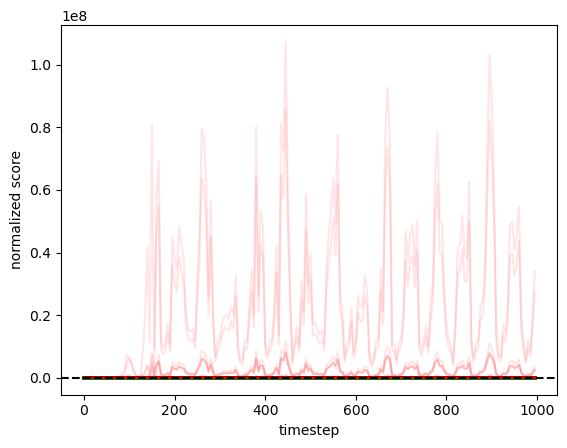

In [71]:
from algs.cd_poly import CDPolynomial

def cd_detector(win, degree=2, basis='cheb', method='qr', eps=0.):
    assert win == 1, "state-based: win=1"
    class Det:
        def __init__(self): self.win = win
        def fit(self, w):  # w: (M, 1, D)
            x = w.reshape(-1, w.shape[-1])
            self.poly = CDPolynomial(
                x, degree=degree, basis=basis, method=method, eps=eps, verbose=True,
            )
            return self
        def score(self, w):  # (M, 1, D) -> (M,)
            return np.asarray(self.poly(w.reshape(-1, w.shape[-1])))
    return Det()

res_cd = get_results(lambda W: cd_detector(W, degree=3), ds, W=1, stride=stride, H=H)
print(res_cd['fpr'], res_cd['det_rate'], res_cd['med_ttd'])
plot_results(res_cd)

In [43]:
def nf_cd_detector(
    win, degree=2, basis='herm', method='qr', eps=0., max_epochs=20,
):
    """Fit a flow, then fit a CD polynomial on the flow's encodings."""
    assert win == 1, "state-based: win=1"
    class Det:
        def __init__(self): self.win = win
        def fit(self, w):  # w: (M, 1, D)
            from flowjax.flows import block_neural_autoregressive_flow
            from flowjax.train import fit_to_data
            x = w.reshape(-1, w.shape[-1])
            f = block_neural_autoregressive_flow(
                key=jr.key(0), base_dist=Normal(jnp.zeros(x.shape[-1])),
            )
            self.flow, _ = fit_to_data(
                key=jr.key(1), dist=f, data=x,
                learning_rate=5e-3, max_epochs=max_epochs,
            )
            self._encode = jax.vmap(self.flow.bijection.inverse)
            z = np.asarray(self._encode(x))
            self.poly = CDPolynomial(
                z, degree=degree, basis=basis, method=method, eps=eps,
            )
            return self
        def score(self, w):  # (M, 1, D) -> (M,)
            x = w.reshape(-1, w.shape[-1])
            z = np.asarray(self._encode(x))
            return np.asarray(self.poly(z))
    return Det()

In [68]:
def run_experiment(env, methods, W=1, stride=1, H=70, alpha=0.1):
    """Run each method on `env`; print + plot results per method.

    methods : dict[str, callable]  — name -> factory(W) -> Det()
    """
    import gc, jax
    ds = get_ds(env)
    results = {}
    for name, factory in methods.items():
        print(f'\n=== {name} on {env} ===')
        res = get_results(factory, ds, W=W, stride=stride, H=H, alpha=alpha)
        print_results(res)
        fig, ax = plt.subplots()
        plot_results(res, ax=ax)
        ax.set_title(name)
        plt.show()
        plt.close(fig)
        results[name] = res
        gc.collect()
        jax.clear_caches()
    return results

## Hopper


=== flow on hopper ===
Train on (875274, 1, 11)


100%|█████████████████████████████| 20/20 [03:02<00:00,  9.14s/it, train=-8.6, val=-8.65]


Scoring 221 trajs
Scoring 220 trajs
Scoring 521 trajs
9.049773755656108 100.0 199.5


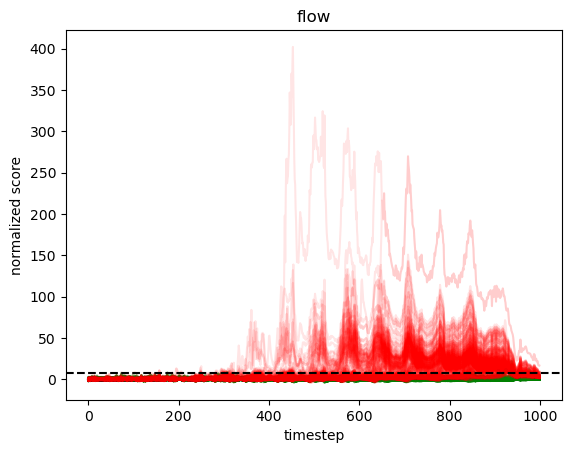


=== cd_poly on hopper ===
Train on (875274, 1, 11)
Data monomials shape: torch.Size([875274, 364])
Moment matrix cond num: 4.364826e+10
Empirical mean of CD poly: 364.0
Scoring 221 trajs
Scoring 220 trajs
Scoring 521 trajs
10.407239819004525 100.0 243.5


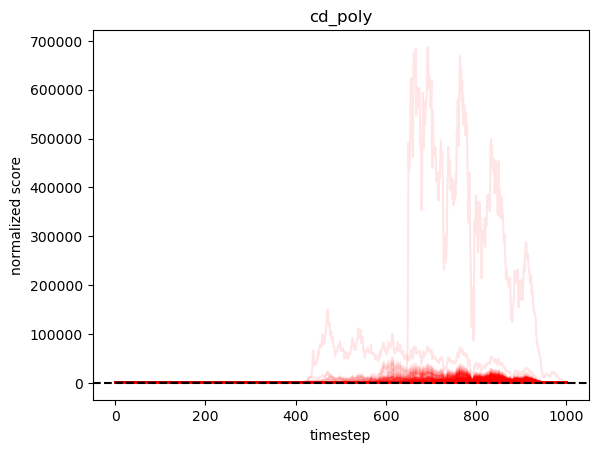


=== nf+cd on hopper ===
Train on (875274, 1, 11)


  5%|█▌                            | 1/20 [00:10<03:26, 10.87s/it, train=-4.5, val=-6.32]

In [ ]:
# Hopper
results = run_experiment('hopper', W=1, stride=1, H=70, methods={
    'flow': flow_detector,
    'cd_poly': lambda W: cd_detector(W, degree=3),
    'nf+cd': lambda W: nf_cd_detector(W, degree=3, basis='herm'),
});

## Humanoid


=== flow on humanoid ===
Train on (89894, 1, 45)


100%|█| 20/20 [01:02<00:00,  3.11s/it, train


Scoring 249 trajs
Scoring 249 trajs
Scoring 501 trajs
11.646586345381527 98.01587301587301 11.0


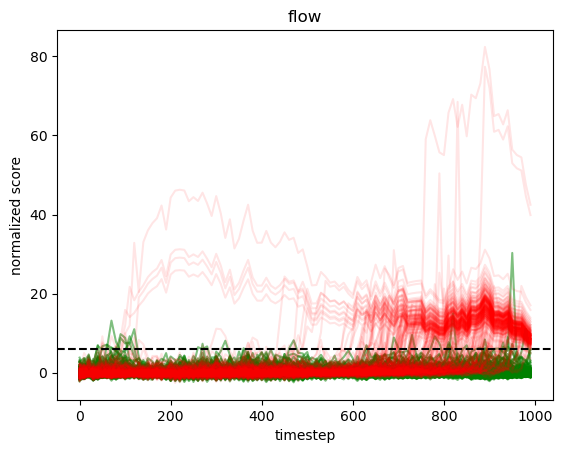


=== cd_poly on humanoid ===
Train on (89894, 1, 45)
Data monomials shape: torch.Size([89894, 1081])
Moment matrix cond num: 3.390829e+09
Empirical mean of CD poly: 1080.9998779296875
Scoring 249 trajs
Scoring 249 trajs
Scoring 501 trajs
10.843373493975903 82.14285714285714 8.0


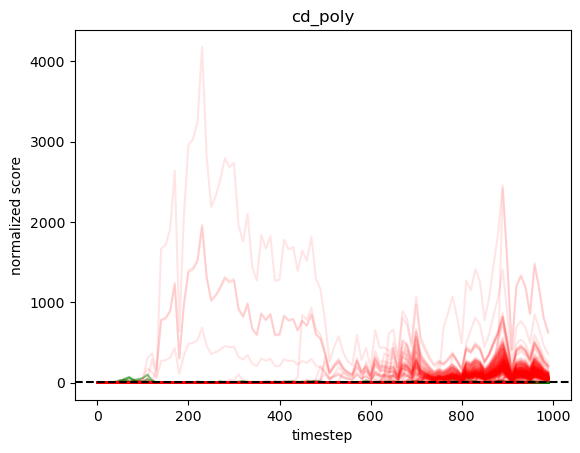

In [72]:
results = run_experiment('humanoid', H=10, stride=10, W=1, methods={
    'flow': flow_detector,
    'cd_poly': lambda W: cd_detector(W, degree=2),
#    'nf+cd': lambda W: nf_cd_detector(W, degree=2, basis='herm'),
});


=== flow on humanoid ===
Train on (88886, 1, 45)


100%|█| 20/20 [01:10<00:00,  3.53s/it, train


Scoring 249 trajs
Scoring 249 trajs
Scoring 501 trajs
10.040160642570282 99.20634920634922 12.0


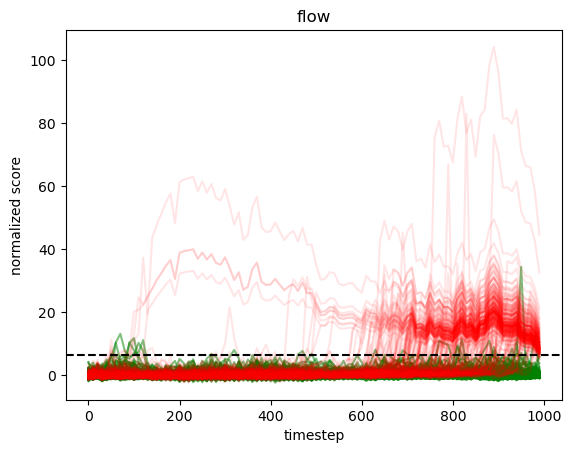


=== cd_poly on humanoid ===
Train on (88886, 1, 45)
Data monomials shape: torch.Size([88886, 1081])
Moment matrix cond num: 4.572287e+09
Empirical mean of CD poly: 1080.9998779296875
Scoring 249 trajs
Scoring 249 trajs
Scoring 501 trajs
10.040160642570282 89.68253968253968 10.0


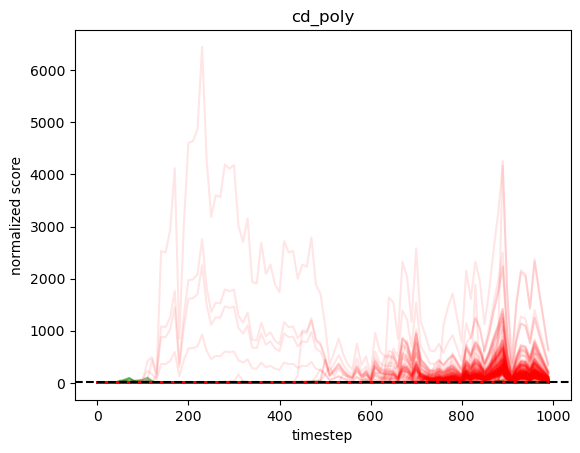

In [74]:
results = run_experiment('humanoid', H=30, stride=10, W=1, methods={
    'flow': flow_detector,
    'cd_poly': lambda W: cd_detector(W, degree=2),
#    'nf+cd': lambda W: nf_cd_detector(W, degree=2, basis='herm'),
});


=== flow on humanoid ===
Train on (49700, 1, 45)


100%|█| 20/20 [00:38<00:00,  1.94s/it, train


Scoring 249 trajs
Scoring 249 trajs
Scoring 501 trajs
10.843373493975903 96.42857142857143 14.0


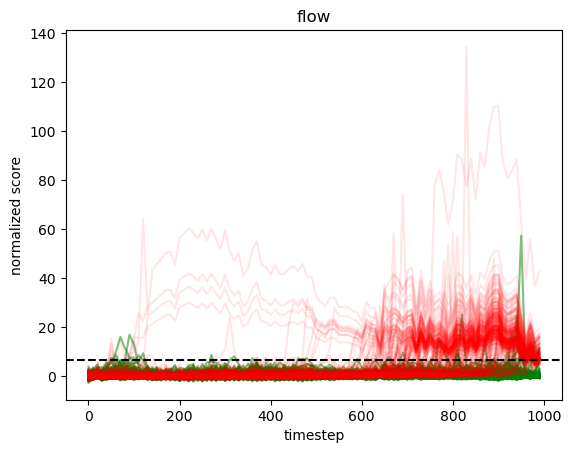


=== cd_poly on humanoid ===
Train on (49700, 1, 45)
Data monomials shape: torch.Size([49700, 1081])
Moment matrix cond num: 4.758076e+09
Empirical mean of CD poly: 1081.0
Scoring 249 trajs
Scoring 249 trajs
Scoring 501 trajs
10.441767068273093 90.07936507936508 11.0


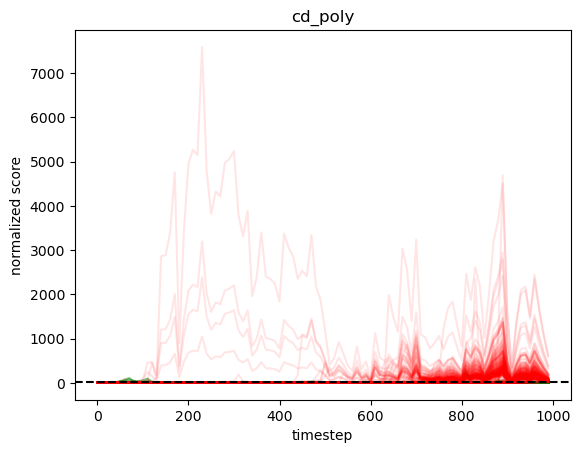

In [73]:
results = run_experiment('humanoid', H=np.inf, stride=10, W=1, methods={
    'flow': flow_detector,
    'cd_poly': lambda W: cd_detector(W, degree=2),
#    'nf+cd': lambda W: nf_cd_detector(W, degree=2, basis='herm'),
});

## inv_pend


=== flow on inv_pend ===
Train on (649124, 1, 4)


100%|█| 20/20 [01:30<00:00,  4.53s/it, train


Scoring 303 trajs
Scoring 303 trajs
Scoring 465 trajs
9.24092409240924 78.39506172839506 14.0


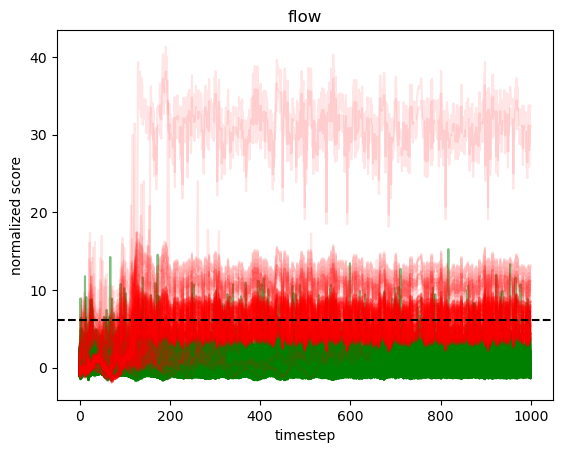


=== cd_poly on inv_pend ===
Train on (649124, 1, 4)
Data monomials shape: torch.Size([649124, 70])
Moment matrix cond num: 6.605906e+08
Empirical mean of CD poly: 70.0
Scoring 303 trajs
Scoring 303 trajs
Scoring 465 trajs
9.900990099009901 100.0 10.0


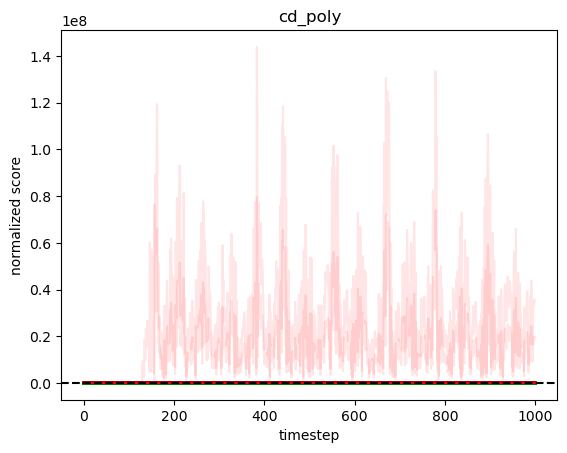

In [81]:
# inv_pend: H = 10
results = run_experiment('inv_pend', H=10, stride=1, W=1, methods={
    'flow': flow_detector,
    'cd_poly': lambda W: cd_detector(W, degree=4),
#    'nf+cd': lambda W: nf_cd_detector(W, degree=4, basis='herm'),
});


=== flow on inv_pend ===
Train on (646074, 1, 4)


100%|█| 20/20 [01:32<00:00,  4.65s/it, train


Scoring 303 trajs
Scoring 303 trajs
Scoring 465 trajs
8.58085808580858 97.53086419753086 14.0


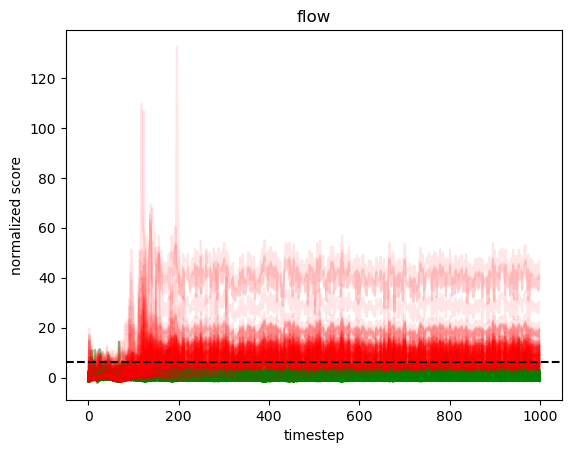


=== cd_poly on inv_pend ===
Train on (646074, 1, 4)
Data monomials shape: torch.Size([646074, 70])
Moment matrix cond num: 1.030834e+09
Empirical mean of CD poly: 70.00000762939453
Scoring 303 trajs
Scoring 303 trajs
Scoring 465 trajs
10.231023102310232 100.0 15.5


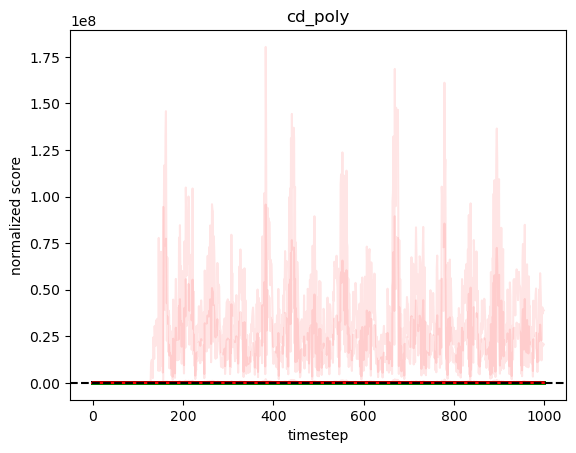

In [85]:
# inv_pend: H = 20
results = run_experiment('inv_pend', H=20, stride=1, W=1, methods={
    'flow': flow_detector,
    'cd_poly': lambda W: cd_detector(W, degree=4),
#    'nf+cd': lambda W: nf_cd_detector(W, degree=4, basis='herm'),
});


=== flow on inv_pend ===
Train on (606000, 1, 4)


100%|█| 20/20 [01:25<00:00,  4.27s/it, train


Scoring 303 trajs
Scoring 303 trajs
Scoring 465 trajs
6.6006600660066 97.53086419753086 21.5


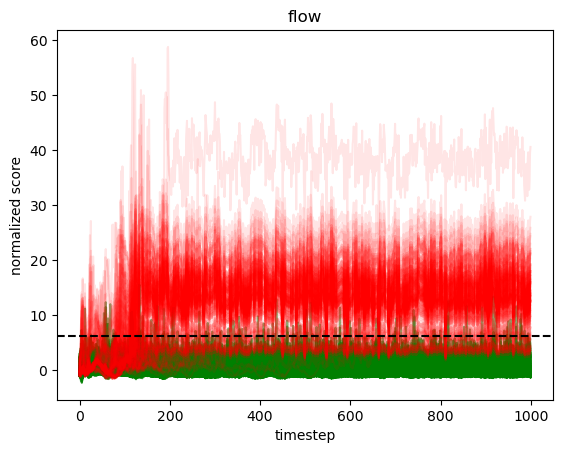


=== cd_poly on inv_pend ===
Train on (606000, 1, 4)
Data monomials shape: torch.Size([606000, 70])
Moment matrix cond num: 2.680692e+11
Empirical mean of CD poly: 69.99998474121094
Scoring 303 trajs
Scoring 303 trajs
Scoring 465 trajs
9.900990099009901 100.0 22.0


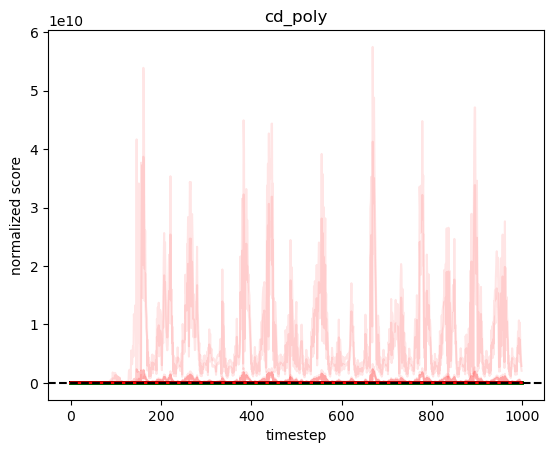

In [84]:
# inv_pend: H = inf
results = run_experiment('inv_pend', H=np.inf, stride=1, W=1, methods={
    'flow': flow_detector,
    'cd_poly': lambda W: cd_detector(W, degree=4),
#    'nf+cd': lambda W: nf_cd_detector(W, degree=4, basis='herm'),
});

## Ant


=== flow on ant ===
Train on (353186, 1, 27)


100%|████████████████████████████| 20/20 [02:26<00:00,  7.34s/it, train=-18.6, val=-18.6]


Scoring 270 trajs
Scoring 270 trajs
Scoring 488 trajs
17.712177121771216 31.336405529953915 47.0


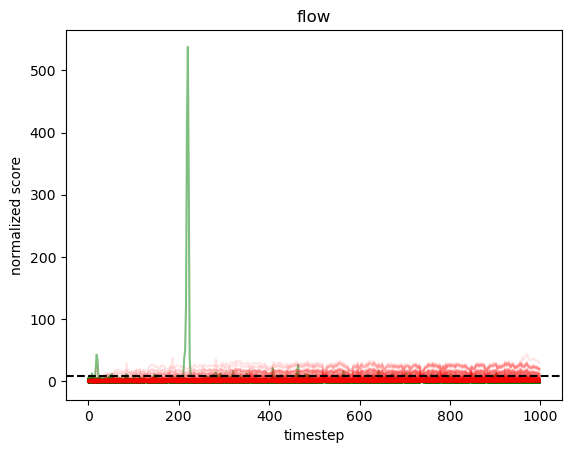


=== cd_poly on ant ===
Train on (353186, 1, 27)
Data monomials shape: torch.Size([353186, 406])
Moment matrix cond num: 1.380451e+06
Empirical mean of CD poly: 406.0
Scoring 270 trajs
Scoring 270 trajs
Scoring 488 trajs
15.129151291512915 28.110599078341014 11.0


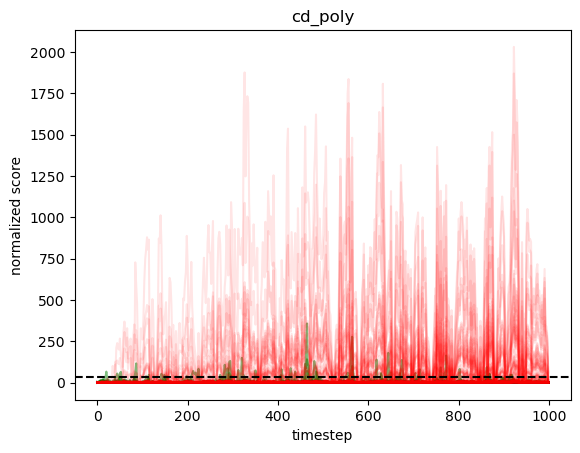

In [83]:
# ant: H = 10
results = run_experiment('ant', H=10, stride=2, W=1, methods={
    'flow': flow_detector,
    'cd_poly': lambda W: cd_detector(W, degree=2),
#    'nf+cd': lambda W: nf_cd_detector(W, degree=2, basis='herm'),
});


=== flow on ant ===
Train on (270000, 1, 27)


100%|████████████████████████████| 20/20 [01:47<00:00,  5.36s/it, train=-19.3, val=-19.5]


Scoring 270 trajs
Scoring 270 trajs
Scoring 488 trajs
16.605166051660518 32.71889400921659 28.0


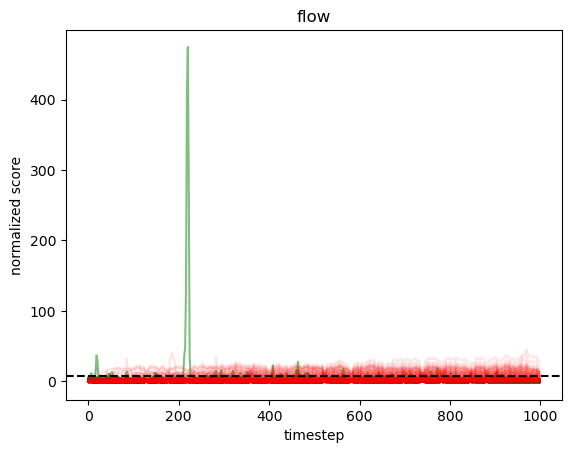


=== cd_poly on ant ===
Train on (270000, 1, 27)
Data monomials shape: torch.Size([270000, 406])
Moment matrix cond num: 1.328904e+06
Empirical mean of CD poly: 406.0
Scoring 270 trajs
Scoring 270 trajs
Scoring 488 trajs
14.760147601476014 29.493087557603687 21.0


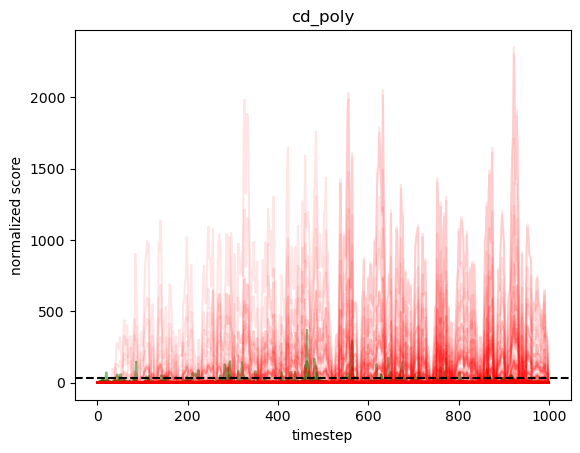


=== nf+cd on ant ===
Train on (270000, 1, 27)


 30%|████████▋                    | 6/20 [00:35<01:23,  5.99s/it, train=-16.1, val=-16.3]


KeyboardInterrupt: 

In [82]:
# ant: H = inf
results = run_experiment('ant', H=np.inf, stride=2, W=1, methods={
    'flow': flow_detector,
    'cd_poly': lambda W: cd_detector(W, degree=2),
    'nf+cd': lambda W: nf_cd_detector(W, degree=2, basis='herm'),
});

## Half Cheetah


=== flow on half_cheetah ===
Train on (333006, 1, 17)


100%|████████████████████████████| 20/20 [01:30<00:00,  4.53s/it, train=-24.9, val=-24.9]


Scoring 281 trajs
Scoring 281 trajs
Scoring 480 trajs
9.9644128113879 19.597989949748744 7.0


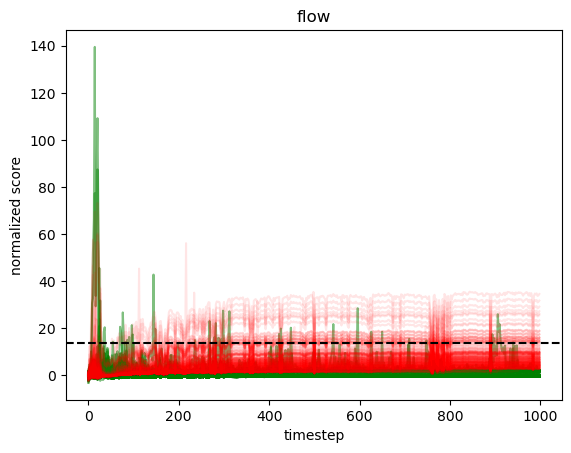


=== cd_poly on half_cheetah ===
Train on (333006, 1, 17)
Data monomials shape: torch.Size([333006, 1140])
Moment matrix cond num: 2.182994e+07
Empirical mean of CD poly: 1140.0
Scoring 281 trajs
Scoring 281 trajs
Scoring 480 trajs
9.252669039145907 54.773869346733676 37.0


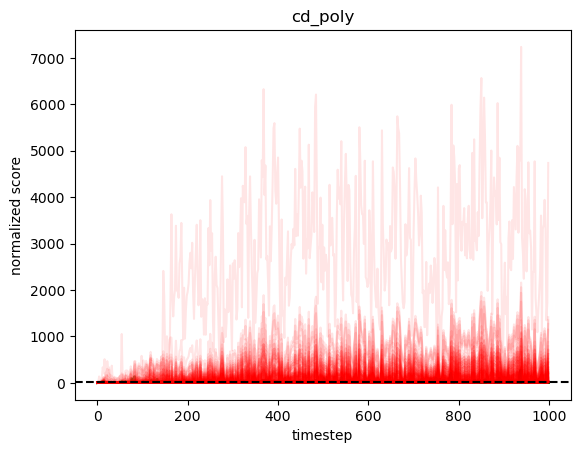

In [84]:
# half cheetah: H = 10
results = run_experiment('half_cheetah', H=10, stride=2, W=1, methods={
    'flow': flow_detector,
    'cd_poly': lambda W: cd_detector(W, degree=3),
#    'nf+cd': lambda W: nf_cd_detector(W, degree=2, basis='herm'),
});


=== flow on half_cheetah ===
Train on (281000, 1, 17)


100%|██████████████████████████████| 20/20 [01:15<00:00,  3.77s/it, train=-34, val=-33.7]


Scoring 281 trajs
Scoring 281 trajs
Scoring 480 trajs
9.9644128113879 33.165829145728644 11.0


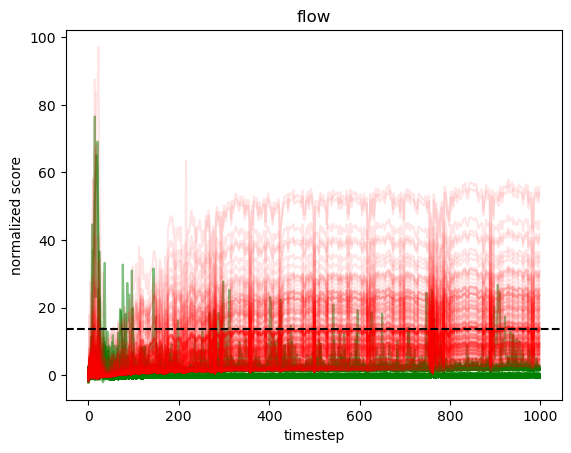


=== cd_poly on half_cheetah ===
Train on (281000, 1, 17)
Data monomials shape: torch.Size([281000, 1140])
Moment matrix cond num: 6.201910e+07
Empirical mean of CD poly: 1140.0001220703125
Scoring 281 trajs
Scoring 281 trajs
Scoring 480 trajs
8.896797153024911 55.778894472361806 55.0


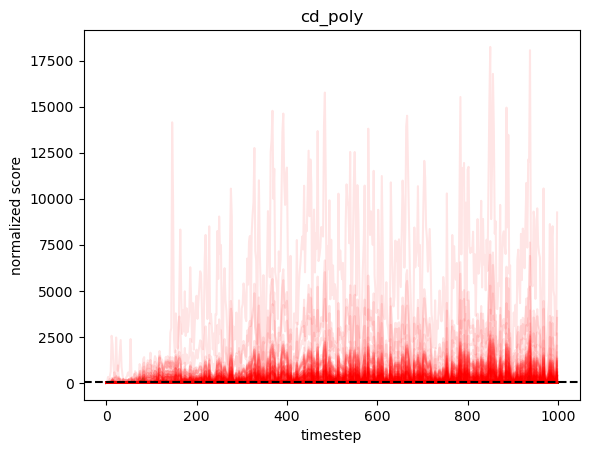

In [85]:
# half cheetah: H = inf
results = run_experiment('half_cheetah', H=np.inf, stride=2, W=1, methods={
    'flow': flow_detector,
    'cd_poly': lambda W: cd_detector(W, degree=3),
#    'nf+cd': lambda W: nf_cd_detector(W, degree=2, basis='herm'),
});

# Experiment 3: sequence-based safety monitoring

In [86]:
from models.conv_ae import ConvAE, train
import torch
from torch.utils.data import DataLoader, Dataset as TDataset

class _DS(TDataset):
  def __init__(self, x):  self.x = x
  def __len__(self):      return len(self.x)
from torch.utils.data import DataLoader, Dataset as TDataset

class _DS(TDataset):
  def __init__(self, x):  self.x = x
  def __len__(self):      return len(self.x)
  def __getitem__(s, i):  return s.x[i]

def conv_ae(win, epochs=10, device='mps', batch_size=2048):
  class Det:
      def __init__(self): self.win = win
      def fit(self, w):
          M, W, D    = w.shape

          out_chan   = max(64, 2 * D)
          latent_dim = max(D, min(W * D // 10, 4 * D))
          print(f'out_chan: {out_chan}, latent_dim: {latent_dim}')
          
          self.model = ConvAE(in_len=W, in_chan=D, out_chan=out_chan,
                              latent_dim=latent_dim)
          dl  = DataLoader(_DS(torch.from_numpy(w).float()),
                           batch_size=128, shuffle=True)
          opt = torch.optim.Adam(self.model.parameters(), lr=3e-4)
          train(self.model, dl, opt, epochs, device)
          return self
      def score(self, w):
          self.model.eval()
          x = torch.from_numpy(w).float()
          out = []
          for i in range(0, len(x), batch_size):
              out.append(self.model.get_scores(x[i:i + batch_size].to(device)).cpu().numpy())
          return np.concatenate(out)
  return Det()

In [87]:
Ws = [2**i for i in range(6)]
Ws

[1, 2, 4, 8, 16, 32]

ConvAE w/ recon score on different W

Train on (108000, 1, 27)
out_chan: 64, latent_dim: 27
Epoch 0: loss=0.1654
Epoch 1: loss=0.0635
Epoch 2: loss=0.0484
Epoch 3: loss=0.0417
Epoch 4: loss=0.0370
Epoch 5: loss=0.0341
Epoch 6: loss=0.0321
Epoch 7: loss=0.0305
Epoch 8: loss=0.0294
Epoch 9: loss=0.0279
Scoring 270 trajs
Scoring 270 trajs
Scoring 488 trajs
Train on (108000, 2, 27)
out_chan: 64, latent_dim: 27
Epoch 0: loss=0.2145
Epoch 1: loss=0.0986
Epoch 2: loss=0.0775
Epoch 3: loss=0.0667
Epoch 4: loss=0.0595
Epoch 5: loss=0.0541
Epoch 6: loss=0.0505
Epoch 7: loss=0.0475
Epoch 8: loss=0.0452
Epoch 9: loss=0.0434
Scoring 270 trajs
Scoring 270 trajs
Scoring 488 trajs
Train on (108000, 4, 27)
out_chan: 64, latent_dim: 27
Epoch 0: loss=0.2327
Epoch 1: loss=0.1223
Epoch 2: loss=0.1002
Epoch 3: loss=0.0883
Epoch 4: loss=0.0813
Epoch 5: loss=0.0763
Epoch 6: loss=0.0726
Epoch 7: loss=0.0690
Epoch 8: loss=0.0665
Epoch 9: loss=0.0642
Scoring 270 trajs
Scoring 270 trajs
Scoring 488 trajs
Train on (107460, 8, 27)
out_chan: 64, latent_

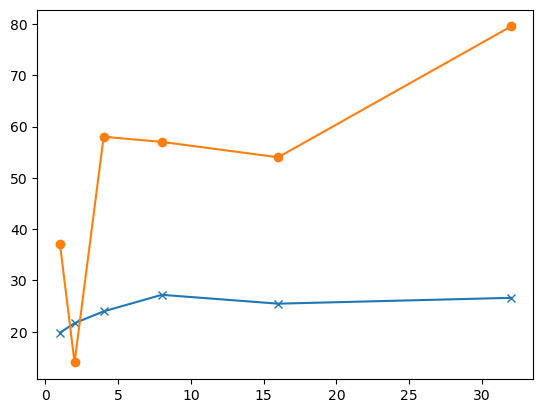

In [89]:
ds = get_ds('ant')
H, stride = np.inf, 5
alpha, seed  = 0.1, 0

dets, ttds = [], []
for W in Ws:
    res = get_results(lambda W: conv_ae(W, epochs=10), ds, W, stride, H, alpha, seed)
    dets.append(res['det_rate'])
    ttds.append(res['med_ttd'])

plt.plot(Ws, dets, marker='x')
plt.plot(Ws, ttds, marker='o')

In [93]:
dets

[19.81566820276498,
 21.658986175115206,
 23.963133640552993,
 27.188940092165897,
 25.462962962962965,
 26.60098522167488]

In [76]:
def conv_cd_detector(win, degree=2, basis='herm', cd_method='qr', eps=0.,
                     epochs=10, latent_dim=None, out_chan=None,
                     device='mps', batch_size=2048):
    """ConvAE encoder + CD polynomial on the latent."""
    class Det:
        def __init__(self): self.win = win
        def _encode(self, w):
            self.model.eval()
            x = torch.from_numpy(w).float()
            zs = []
            with torch.no_grad():
                for i in range(0, len(x), batch_size):
                    _, z = self.model(x[i:i + batch_size].to(device))
                    zs.append(z.cpu().numpy())
            return np.concatenate(zs)
        def fit(self, w):  # w: (M, W, D)
            M, W, D = w.shape
            oc = out_chan if out_chan is not None else max(64, 2 * D)
            ld = latent_dim if latent_dim is not None else min(2 * D, 16)
            print(f'out_chan: {oc}, latent_dim: {ld}')
            self.model = ConvAE(in_len=W, in_chan=D, out_chan=oc, latent_dim=ld)
            dl  = DataLoader(_DS(torch.from_numpy(w).float()),
                             batch_size=128, shuffle=True)
            opt = torch.optim.Adam(self.model.parameters(), lr=3e-4)
            train(self.model, dl, opt, epochs, device)
            z = self._encode(w)
            self.poly = CDPolynomial(
                z, degree=degree, basis=basis, method=cd_method, eps=eps,
            )
            return self
        def score(self, w):  # (M, W, D) -> (M,)
            return np.asarray(self.poly(self._encode(w)))
    return Det()

Train on (99400, 1, 45)
out_chan: 90, latent_dim: 16
Epoch 0: loss=0.2183
Epoch 1: loss=0.0897
Epoch 2: loss=0.0718
Epoch 3: loss=0.0644
Epoch 4: loss=0.0593
Epoch 5: loss=0.0558
Epoch 6: loss=0.0533
Epoch 7: loss=0.0515
Epoch 8: loss=0.0500
Epoch 9: loss=0.0484
Scoring 249 trajs
Scoring 249 trajs
Scoring 501 trajs
Train on (99400, 2, 45)
out_chan: 90, latent_dim: 16
Epoch 0: loss=0.2458
Epoch 1: loss=0.1134
Epoch 2: loss=0.0924
Epoch 3: loss=0.0829
Epoch 4: loss=0.0778
Epoch 5: loss=0.0730
Epoch 6: loss=0.0700
Epoch 7: loss=0.0678
Epoch 8: loss=0.0660
Epoch 9: loss=0.0644
Scoring 249 trajs
Scoring 249 trajs
Scoring 501 trajs
Train on (99400, 4, 45)
out_chan: 90, latent_dim: 16
Epoch 0: loss=0.2445
Epoch 1: loss=0.1287
Epoch 2: loss=0.1069
Epoch 3: loss=0.0961
Epoch 4: loss=0.0901
Epoch 5: loss=0.0860
Epoch 6: loss=0.0827
Epoch 7: loss=0.0805
Epoch 8: loss=0.0787
Epoch 9: loss=0.0773
Scoring 249 trajs
Scoring 249 trajs
Scoring 501 trajs
Train on (98903, 8, 45)
out_chan: 90, latent_dim:

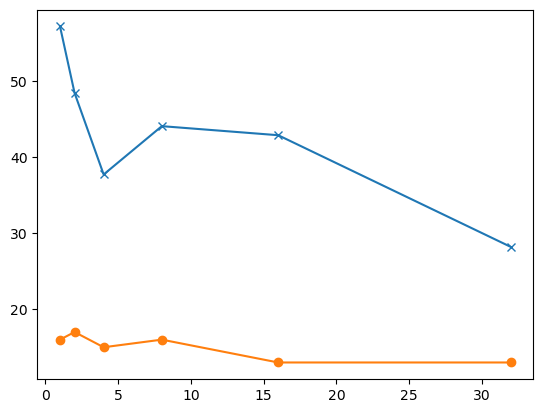

In [79]:
ds = get_ds('humanoid')
H, stride = np.inf, 5
alpha, seed  = 0.1, 0

dets, ttds = [], []
for W in Ws:
    res = get_results(lambda W: conv_cd_detector(W, epochs=10, degree=3), ds, W, stride, H, alpha, seed)
    dets.append(res['det_rate'])
    ttds.append(res['med_ttd'])

plt.plot(Ws, dets, marker='x')
plt.plot(Ws, ttds, marker='o')

In [80]:
dets

[57.14285714285714,
 48.41269841269841,
 37.698412698412696,
 44.047619047619044,
 42.857142857142854,
 28.174603174603174]

Train on (49700, 2, 45)


100%|█████████████████████████████| 20/20 [01:12<00:00,  3.63s/it, train=-108, val=-106]


Scoring 249 trajs
Scoring 249 trajs
Scoring 501 trajs
9.63855421686747 96.82539682539682 14.0


<Axes: xlabel='timestep', ylabel='normalized score'>

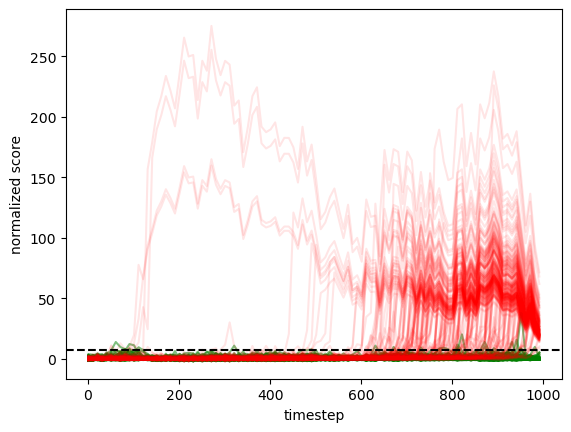

In [96]:
ds = get_ds('humanoid')
W, H, stride = 2, np.inf, 10
alpha, seed  = 0.1, 0

res = get_results(lambda W: flow_detector(W), ds, W, stride, H, alpha, seed)

print_results(res)
plot_results(res)

Train on (70728, 3, 27)


100%|█████████████████████████████| 20/20 [01:33<00:00,  4.65s/it, train=-114, val=-114]


Scoring 270 trajs
Scoring 270 trajs
Scoring 488 trajs
13.284132841328415 23.502304147465438 62.0


<Axes: xlabel='timestep', ylabel='normalized score'>

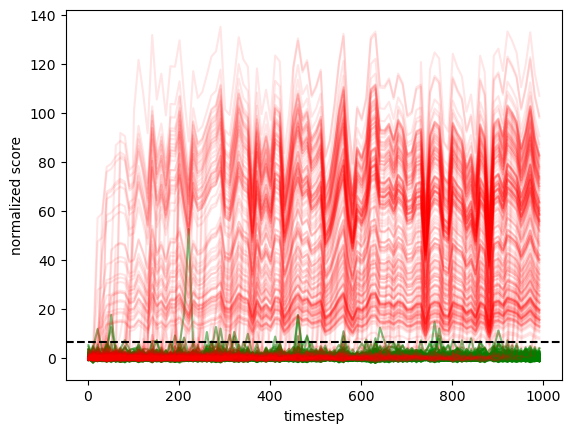

In [100]:
ds = get_ds('ant')
W, H, stride = 3, 10, 10
alpha, seed  = 0.1, 0

res = get_results(lambda W: flow_detector(W), ds, W, stride, H, alpha, seed)

print_results(res)
plot_results(res)